# 01 · Exploración del dataset
**TP — Redes Neuronales Convolucionales · Radiografías de tórax veterinarias**

Objetivo: conocer el dataset antes de modelar — conteo por clase, balance, ejemplos visuales, tamaños y detección de imágenes corruptas.

In [1]:
# =========================================================
# CONFIGURACIÓN  ·  EDITAR BASE_DIR si hace falta
# =========================================================
from google.colab import drive
drive.mount('/content/drive')

import os

# Carpeta de Drive que CONTIENE "Imagenes OK" y "Imagenes Patologicas".
# Ajustá esta ruta a donde estén tus carpetas.
BASE_DIR = '/content/drive/MyDrive/TP_Final Aprendizaje Automatico'

OK_DIR  = os.path.join(BASE_DIR, 'Imagenes OK')
PAT_DIR = os.path.join(BASE_DIR, 'Imagenes Patologicas')

# Carpeta donde se guardará la partición train/val/test (notebook 02)
DATASET_DIR = os.path.join(BASE_DIR, 'dataset')
# Carpeta donde se guardarán los modelos entrenados
MODELS_DIR  = os.path.join(BASE_DIR, 'modelos')
os.makedirs(MODELS_DIR, exist_ok=True)

# Hiperparámetros globales compartidos
IMG_SIZE = (224, 224)
BATCH    = 32
SEED     = 42

# Las carpetas se ordenan alfabéticamente: 'ok'=0, 'patologica'=1
# => la clase POSITIVA (la que nos importa) es 'patologica' = 1
CLASS_NAMES = ['ok', 'patologica']
print('OK_DIR :', OK_DIR)
print('PAT_DIR:', PAT_DIR)

Mounted at /content/drive
OK_DIR : /content/drive/MyDrive/TP_Final Aprendizaje Automatico/Imagenes OK
PAT_DIR: /content/drive/MyDrive/TP_Final Aprendizaje Automatico/Imagenes Patologicas


## 1. Conteo de imágenes por clase

In [2]:
from pathlib import Path

VALID_EXT = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tif', '.tiff', '.webp'}

def listar_imagenes(carpeta):
    # rglob('*') recorre TODAS las subcarpetas, no solo el primer nivel
    return [p for p in Path(carpeta).rglob('*')
            if p.suffix.lower() in VALID_EXT and p.is_file()]

ok_files  = listar_imagenes(OK_DIR)
pat_files = listar_imagenes(PAT_DIR)
n_ok, n_pat = len(ok_files), len(pat_files)
total = n_ok + n_pat

print(f'Normal (ok)      : {n_ok}')
print(f'Patológica       : {n_pat}')
print(f'TOTAL            : {total}')
print(f'Proporción ok    : {n_ok/total:.1%}')
print(f'Proporción pat.  : {n_pat/total:.1%}')

Normal (ok)      : 245
Patológica       : 196
TOTAL            : 441
Proporción ok    : 55.6%
Proporción pat.  : 44.4%


## 2. Balance de clases

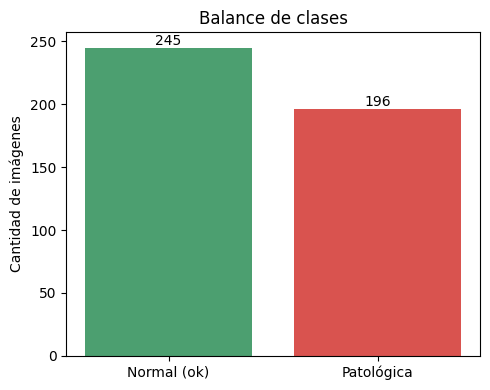

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
bars = plt.bar(['Normal (ok)', 'Patológica'], [n_ok, n_pat],
               color=['#4C9F70', '#D9534F'])
plt.bar_label(bars)
plt.ylabel('Cantidad de imágenes')
plt.title('Balance de clases')
plt.tight_layout()
plt.show()

## 3. Ejemplos de cada clase

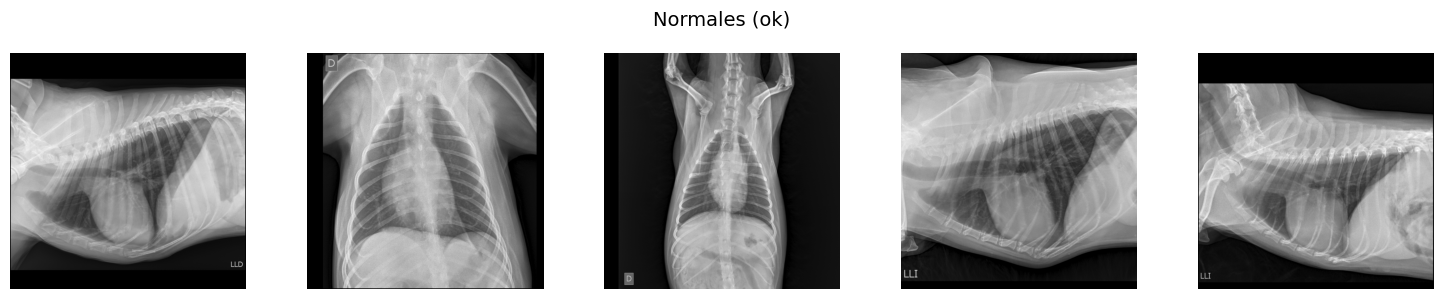

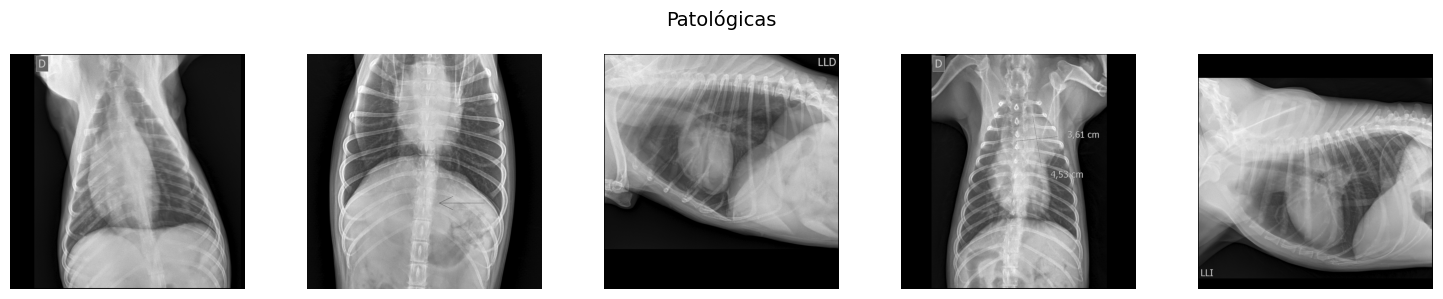

In [4]:
from PIL import Image
import random
random.seed(SEED)

def mostrar_muestras(files, titulo, n=5):
    muestras = random.sample(files, min(n, len(files)))
    fig, axes = plt.subplots(1, n, figsize=(3*n, 3))
    fig.suptitle(titulo, fontsize=14)
    for ax, f in zip(axes, muestras):
        ax.imshow(Image.open(f).convert('L'), cmap='gray')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

mostrar_muestras(ok_files,  'Normales (ok)')
mostrar_muestras(pat_files, 'Patológicas')

## 4. Tamaños, modo de color e imágenes corruptas

Ancho  -> min 1024  max 1320
Alto   -> min 797   max 1456
Modos de color: {'RGB': 441}
Imágenes corruptas: 0


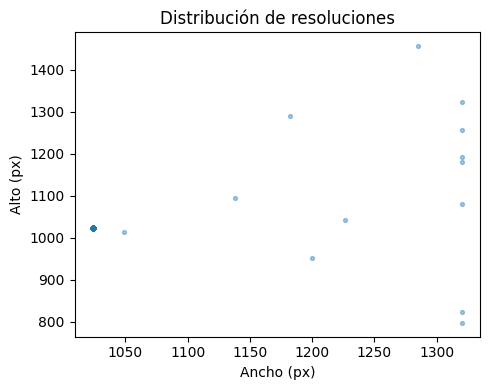

In [5]:
import collections

sizes, modes, corruptas = [], collections.Counter(), []
for f in ok_files + pat_files:
    try:
        with Image.open(f) as im:
            sizes.append(im.size)        # (ancho, alto)
            modes[im.mode] += 1          # 'L' = escala de grises, 'RGB', etc.
    except Exception as e:
        corruptas.append((f.name, str(e)))

anchos = [s[0] for s in sizes]
altos  = [s[1] for s in sizes]
print(f'Ancho  -> min {min(anchos)}  max {max(anchos)}')
print(f'Alto   -> min {min(altos)}   max {max(altos)}')
print('Modos de color:', dict(modes))
print('Imágenes corruptas:', len(corruptas))
for nombre, err in corruptas:
    print('  -', nombre, err)

plt.figure(figsize=(5,4))
plt.scatter(anchos, altos, s=8, alpha=0.4)
plt.xlabel('Ancho (px)'); plt.ylabel('Alto (px)')
plt.title('Distribución de resoluciones')
plt.tight_layout(); plt.show()

## 5. Conclusiones de la exploración

> **Completar tras correr la notebook.** Anotar: conteos definitivos, si el dataset está balanceado, si las imágenes son escala de grises (modo `L`), el rango de resoluciones (justifica el resize a 224×224) y si hubo imágenes corruptas para descartar.

Próximo paso → **02_preparacion_dataset.ipynb**: partición estratificada 70/15/15.